In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print('Libraries imported successfully.')

Libraries imported successfully.


In [ ]:
print('Loading MNIST dataset...')
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print('MNIST dataset loaded successfully.')

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST dataset loaded successfully.


In [ ]:
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)


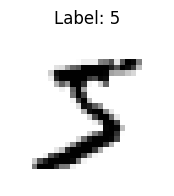

In [ ]:
plt.figure(figsize=(2, 2))
plt.imshow(x_train[0], cmap=plt.cm.binary)
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

In [ ]:
print('Normalizing pixel values...')
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

print(f"Shape of x_train_normalized: {x_train_normalized.shape}, dtype: {x_train_normalized.dtype}")
print(f"Shape of x_test_normalized: {x_test_normalized.shape}, dtype: {x_test_normalized.dtype}")
print('Pixel values normalized successfully.')

Normalizing pixel values...
Shape of x_train_normalized: (60000, 28, 28), dtype: float32
Shape of x_test_normalized: (10000, 28, 28), dtype: float32
Pixel values normalized successfully.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

print('Designing the neural network model...')

model = Sequential([
    Flatten(input_shape=(28, 28)), # Input layer: Flattens the 28x28 image to a 1D array
    Dense(128, activation='relu'), # Hidden layer: 128 neurons with ReLU activation
    Dense(10, activation='softmax')  # Output layer: 10 neurons (for 10 classes) with Softmax activation
])

model.summary()
print('Neural network model designed successfully.')

Designing the neural network model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Neural network model designed successfully.


In [ ]:
print('Compiling the neural network model...')
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print('Neural network model compiled successfully.')

Compiling the neural network model...
Neural network model compiled successfully.


In [ ]:
print('Training the neural network model...')
history = model.fit(x_train_normalized, y_train, epochs=10, validation_split=0.2)
print('Neural network model trained successfully.')

Training the neural network model...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9171 - loss: 0.2909 - val_accuracy: 0.9562 - val_loss: 0.1561
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9623 - loss: 0.1298 - val_accuracy: 0.9662 - val_loss: 0.1147
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9738 - loss: 0.0899 - val_accuracy: 0.9689 - val_loss: 0.1059
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9797 - loss: 0.0677 - val_accuracy: 0.9712 - val_loss: 0.0941
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9844 - loss: 0.0517 - val_accuracy: 0.9746 - val_loss: 0.0828
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9879 - loss: 0.0404 - val_accuracy: 0.9764 - val_loss: 0.0879
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9906 - loss: 0.0313 - val_accuracy: 0.9745 - val_loss: 0.0899
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

In [ ]:
print('Evaluating model performance...')
loss, accuracy = model.evaluate(x_test_normalized, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print('Model evaluation complete.')

Evaluating model performance...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9764 - loss: 0.0877

Test Loss: 0.0877
Test Accuracy: 0.9764
Model evaluation complete.


Plotting training and validation accuracy curves...


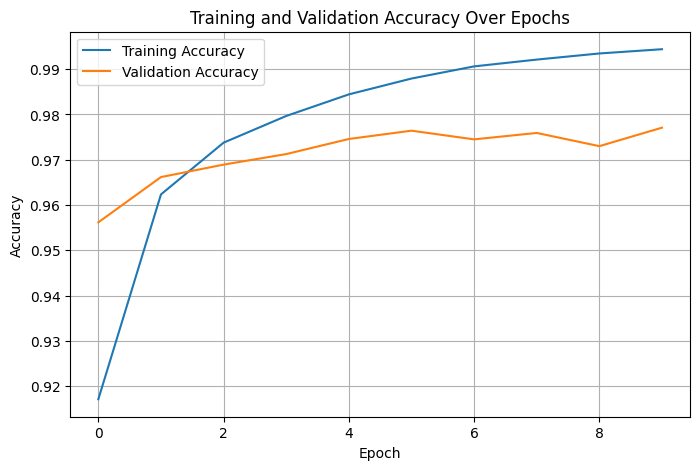

Accuracy curves plotted successfully.


In [ ]:
print('Plotting training and validation accuracy curves...')

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print('Accuracy curves plotted successfully.')

Making predictions on sample images...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


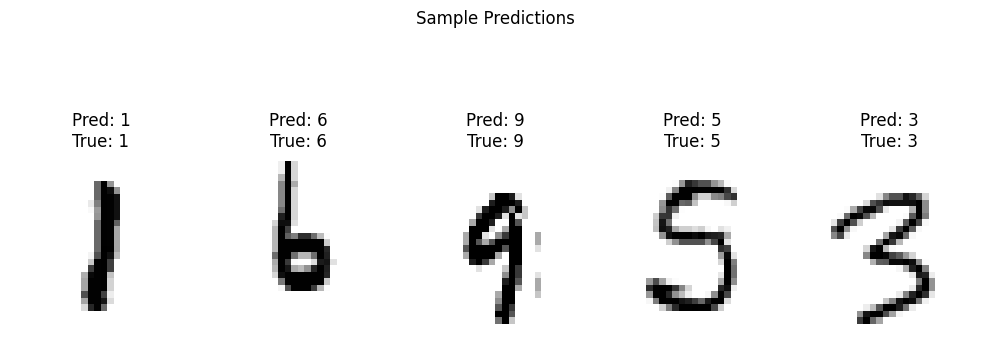

Predictions displayed successfully.


In [ ]:
print('Making predictions on sample images...')

num_predictions = 5

# Select random indices from the test set
random_indices = np.random.choice(len(x_test_normalized), num_predictions, replace=False)

plt.figure(figsize=(10, 4))
for i, idx in enumerate(random_indices):
    image = x_test_normalized[idx]
    true_label = y_test[idx]

    # The model expects a batch of images, so we add an extra dimension
    prediction = model.predict(np.expand_dims(image, axis=0))
    predicted_label = np.argmax(prediction)

    plt.subplot(1, num_predictions, i + 1)
    plt.imshow(image, cmap=plt.cm.binary)
    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}")
    plt.axis('off')

plt.suptitle('Sample Predictions', y=1.05)
plt.tight_layout()
plt.show()
print('Predictions displayed successfully.')

Enter the path to the image file for prediction: /content/download.png


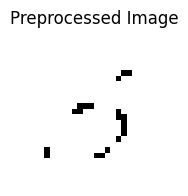

Making prediction for image: /content/download.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Prediction complete. The model predicts the digit is: 5


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# --- Function to preprocess image for MNIST model ---
def preprocess_image(image_path, threshold=0.5):
    try:
        # Open image, convert to grayscale (0=black, 255=white)
        img = Image.open(image_path).convert('L')
        img = img.resize((28, 28)) # Resize to 28x28 pixels
        img_array = np.array(img).astype('float32') / 255.0 # Normalize to 0.0-1.0 (0.0=black, 1.0=white)

        # Invert colors: MNIST has white digits on a black background (high values for digit, low for background).
        # If the input image is black digit on white background, it needs inversion.
        # We assume the user draws a dark digit on a light background.
        # So, invert the array: 0.0 (background) becomes 1.0 (digit), and 1.0 (digit) becomes 0.0 (background).
        img_array = 1.0 - img_array

        # Apply a binary threshold to make the digit more distinct (strictly black/white)
        # Pixels above threshold become 1.0 (white digit), below become 0.0 (black background)
        img_array = (img_array > threshold).astype('float32')

        # Display the preprocessed image for user verification
        plt.figure(figsize=(2, 2))
        plt.imshow(img_array, cmap=plt.cm.binary) # Display with black background, white digit
        plt.title("Preprocessed Image")
        plt.axis('off')
        plt.show()

        img_array = np.expand_dims(img_array, axis=0) # Add batch dimension for model prediction
        return img_array
    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
        return None
    except Exception as e:
        print(f"Error processing image: {e}")
        return None

# --- Main prediction logic ---
image_file_path = input("Enter the path to the image file for prediction: ")

preprocessed_image = preprocess_image(image_file_path)

if preprocessed_image is not None:
    print(f"Making prediction for image: {image_file_path}")
    # The model expects a batch of images, which preprocess_image already provides
    prediction_probabilities = model.predict(preprocessed_image)
    predicted_label = np.argmax(prediction_probabilities)

    print(f"Prediction complete. The model predicts the digit is: {predicted_label}")
else:
    print("Could not make prediction due to image processing error.")